<a href="https://colab.research.google.com/github/fvangool/Deep-Learning-Specialization-Coursera/blob/main/XGB_V20.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install wandb -qU

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.2/27.2 MB 87.2 MB/s eta 0:00:00


Device      : cuda
Seeds       : [42, 123, 2024, 7, 314]
N_FOLDS     : 5
Total CV    : 25 folds
learning_rate: 0.030495


wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: WARNING [wandb.login()] Changing session credentials to explicit value for https://api.wandb.ai.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc


  W&B run: https://wandb.ai/wblackstone-twilight-signals/ps-s6e4-irrigation/runs/4hp5gonv

[1] Loading data...
  Competition rows : 630,000
  Orig rows        : 10,000
  Combined train   : 640,000
  Test             : 270,000
  [W&B] artifact logged: training_data
  Hard examples    : 7,377 rows loaded ✅

[2] Engineering features (v20)...
  All 11 v20 features confirmed ✅

[3] Label encoding categoricals...

[4] Building pairwise interactions (CAT×CAT + CAT×NUM)...


100%|██████████| 171/171 [01:27<00:00,  1.95it/s]


  Kept 116 interaction columns

[5] Preparing feature matrices...
  Base features : 95
  TE columns    : 116
  Class dist    : {np.int32(0): np.int64(375781), np.int32(1): np.int64(242874), np.int32(2): np.int64(21345)}

[6] Multi-seed CV (5 seeds × 5 folds)...

────────────────────────────────────────────────────────────
  SEED 42  (1/5)
────────────────────────────────────────────────────────────

  Fold 1/5 | Seed 42
[0]	val-mlogloss:1.05623	val-bal_acc:0.97312
[200]	val-mlogloss:0.06784	val-bal_acc:0.97689
[400]	val-mlogloss:0.05950	val-bal_acc:0.97845
[600]	val-mlogloss:0.05636	val-bal_acc:0.97919
[800]	val-mlogloss:0.05456	val-bal_acc:0.97921
[905]	val-mlogloss:0.05390	val-bal_acc:0.97893
    BA=0.97893 | iter=605 | 1m 54s

  Fold 2/5 | Seed 42
[0]	val-mlogloss:1.05620	val-bal_acc:0.97398
[200]	val-mlogloss:0.06690	val-bal_acc:0.97734
[400]	val-mlogloss:0.05852	val-bal_acc:0.97818
[600]	val-mlogloss:0.05558	val-bal_acc:0.97878
[800]	val-mlogloss:0.05382	val-bal_acc:0.97872
[953]	

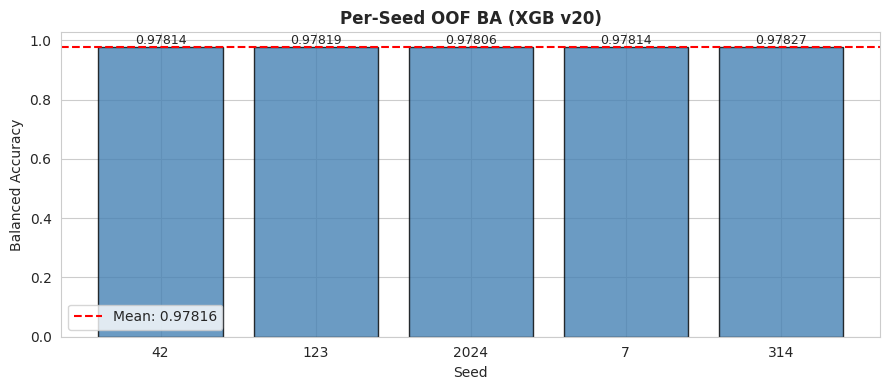

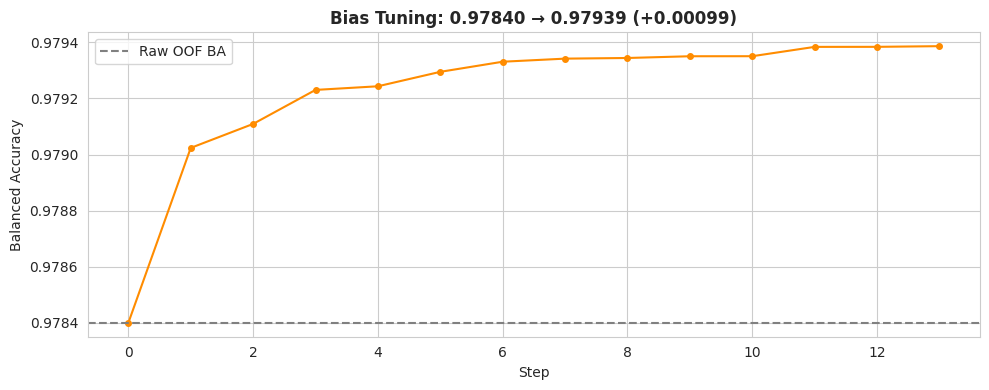

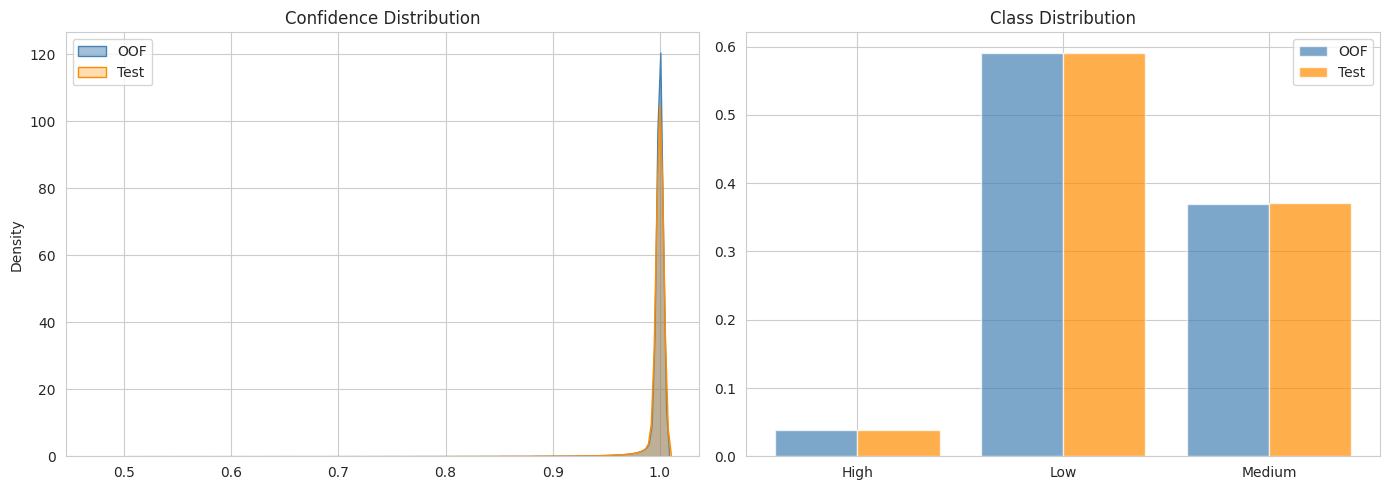


[9] Pseudolabeling (asymmetric thresholds)...
  Thresholds: Low=0.97 | Medium=0.8 | High=0.97
  High-confidence test samples: 261,489
    Low: 153,984
    Medium: 98,370
    High: 9,135
  Retraining on 891,489 rows (261,489 pseudo) for 712 rounds...
  Pseudolabeling complete.

[10] Saving...
  oof_xgb_v20.npy   (630000, 3)
  pred_xgb_v20.npy  (270000, 3)
  Shape assertions passed ✅
  [W&B] artifact logged: oof_xgb_v20
  [W&B] artifact logged: pred_xgb_v20

  Submission: /content/submission_xgb_v20.csv
Irrigation_Need
Low       159484
Medium     99849
High       10667

XGB v20 SUMMARY
  Seeds          : [42, 123, 2024, 7, 314]
  Per-seed BAs   : [np.float64(0.97814), np.float64(0.97819), np.float64(0.97806), np.float64(0.97814), np.float64(0.97827)]
  Mean seed BA   : 0.978160 ± 0.000070
  Averaged raw BA: 0.978399
  Biased BA      : 0.979387 (+0.000988)
  Biases         : [-1.12 -0.73  1.  ]
  Avg best iter  : 712
  Runtime        : 50m 5s


avg_best_iter,▁
bias_correction,▁
bias_high,▁
bias_low,▁
bias_medium,▁
fold,▃▅▆█▁▃▅▆█▁▃▅▆█▁▃▅▆█▁▃▅▆█
fold_ba,▅▆▄▂▂▅▅█▃▄▄▄▃▇▆▃▅▆▃▁▆█▂▇
fold_best_iter,▄█▅▁▄▆▄▇▄▅▁▇▆▅▃▃▆▄▃▄▇▃▄▃
fold_elapsed_s,▆█▆▄▅▆▅▇▅▅▄▅▅▄▃▃▄▂▁▂▃▁▂▁
global_fold,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
+33,...


In [6]:
"""
XGBoost v20 — W&B Integration
==============================
Changes vs v19:
  W&B INTEGRATION
  ───────────────
  1. Artifact versioning: OOF/pred .npy files + training data logged as W&B Artifacts
  2. Fold-level + global BA tracking: searchable experiment table
  3. Hard-example confusion matrix: per-run comparison on the 7,357 hard rows
  4. Config tracking: augmentation method, data source, all hyperparams logged

  All W&B calls are wrapped in try/except so a W&B failure never crashes training.

UNCHANGED FROM v19
──────────────────
  - Score reconstruction features (margin_Medium_wins etc.)
  - Boundary zone features (magic_score_soft, at_magic_boundary etc.)
  - Fixed pseudolabelling (asymmetric thresholds, post-bias, downweighted)
  - Native xgb.train() API with feval_bal_acc
  - Optuna-tuned hyperparameters
  - CAT_ONLY_PAIRS pairwise interactions (RAM fix)
  - numpy hstack DMatrix construction (RAM fix)
  - del train_eng/test_eng after Section 5 (RAM fix)
  - Multi-seed (5 seeds × 5 folds)
  - Bias tuning (logit-space coordinate descent)
  - Telegram notifier + heartbeat

SAVE CONVENTION
───────────────
  oof_xgb_v20.npy        (n_competition, 3)  Low=0  Med=1  High=2
  pred_xgb_v20.npy       (n_test, 3)
  oof_xgb_v20_biased.npy  (alias)
  pred_xgb_v20_biased.npy (alias)
"""

# ============================================================
# SETUP — install W&B if needed (run this cell first on Colab)
# !pip install wandb -q
# ============================================================

# ============================================================
# IMPORTS
# ============================================================
import gc
import os
import json
import time
import random
import warnings
import threading
import traceback
import urllib.request
from contextlib import contextmanager
from itertools import combinations

os.environ["PYTHONHASHSEED"] = "42"
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import xgboost as xgb
import wandb
from google.colab import userdata
from sklearn.preprocessing import LabelEncoder, TargetEncoder
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, confusion_matrix
from scipy.special import logit
from tqdm import tqdm

sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

# ============================================================
# SECTION 0 — CONFIGURATION
# ============================================================
TRAIN_PATH    = "/content/drive/MyDrive/irrigation_need_v15/train.csv"
TEST_PATH     = "/content/drive/MyDrive/irrigation_need_v15/test.csv"
ORIGINAL_PATH = "/content/drive/MyDrive/irrigation_need_v15/irrigation_prediction.csv"
OOF_DIR       = "/content/drive/MyDrive/irrigation_need_v15/"
SUB_DIR       = "/content/"

# Hard example indices from hard_example_mining.py
HARD_IDX_PATH = "/content/drive/MyDrive/irrigation_need_v15/hard_example_indices.npy"

TELEGRAM_BOT_TOKEN = "8755783601:AAGuCUzM6CdgjA825tep5f5zj0FNd7iSkp4"
TELEGRAM_CHAT_ID   = "5422067007"
TELEGRAM_ENABLED   = True

# ── W&B config ────────────────────────────────────────────────────
WANDB_PROJECT  = "ps-s6e4-irrigation"
WANDB_ENTITY   = "wblackstone-twilight-signals"         # set to your W&B username if needed
WANDB_ENABLED  = True

TAG      = "xgb_v20"
RUN_NAME = "XGB v20"

SEEDS   = [42, 123, 2024, 7, 314]
N_FOLDS = 5
TARGET  = "Irrigation_Need"
N_CLASSES = 3

TARGET_MAPPING     = {"Low": 0, "Medium": 1, "High": 2}
INV_TARGET_MAPPING = {0: "Low", 1: "Medium", 2: "High"}
CLASS_NAMES        = ["Low", "Medium", "High"]

# Augmentation metadata (logged to W&B config)
DATA_CONFIG = {
    "train_file"          : "train.csv",          # change to augmented_train.csv if used
    "augmentation_method" : "none",               # "none" | "SMOTE-NC" | "B2BGAN"
    "smote_rows_added"    : 0,                    # set to 5638 if using augmented
    "hard_case_version"   : "v1_top4_unanimous",
    "pseudo_label_version": "v2_asymmetric_thresh",
    "use_original_data"   : True,
}

PSEUDO_THRESH_BY_CLASS = {
    0: 0.97,   # Low
    1: 0.80,   # Medium
    2: 0.97,   # High
}
PSEUDO_WEIGHT = 0.7

NUMS = [
    "Soil_pH", "Soil_Moisture", "Organic_Carbon",
    "Electrical_Conductivity", "Temperature_C", "Humidity",
    "Rainfall_mm", "Sunlight_Hours", "Wind_Speed_kmh",
    "Field_Area_hectare", "Previous_Irrigation_mm",
]
CATS = [
    "Soil_Type", "Crop_Type", "Crop_Growth_Stage", "Season",
    "Irrigation_Type", "Water_Source", "Mulching_Used", "Region",
]

SOIL_THRESH = 25
RAIN_THRESH = 300
TEMP_THRESH = 30
WIND_THRESH = 10

LOGIT_COEFS = {
    "Low": {
        "intercept": 16.3173, "soil_lt_25": -11.0237, "temp_gt_30": -5.8559,
        "rain_lt_300": -10.8500, "wind_gt_10": -5.8284,
        "Flowering": -5.4155, "Harvest": 5.5073, "Sowing": 5.2299,
        "Vegetative": -5.4617, "Mulch_No": -3.0014, "Mulch_Yes": 2.8613,
    },
    "Medium": {
        "intercept": 4.6524, "soil_lt_25": 0.3290, "temp_gt_30": -0.0204,
        "rain_lt_300": 0.1542, "wind_gt_10": 0.0841,
        "Flowering": 0.3586, "Harvest": -0.1348, "Sowing": -0.3547,
        "Vegetative": 0.3334, "Mulch_No": 0.1883, "Mulch_Yes": 0.0142,
    },
    "High": {
        "intercept": -20.9697, "soil_lt_25": 10.6947, "temp_gt_30": 5.8763,
        "rain_lt_300": 10.6958, "wind_gt_10": 5.7444,
        "Flowering": 5.0569, "Harvest": -5.3725, "Sowing": -4.8752,
        "Vegetative": 5.1283, "Mulch_No": 2.8131, "Mulch_Yes": -2.8755,
    },
}

XGB_PARAMS = dict(
    max_depth            = 4,
    learning_rate        = 0.030495387759654796,
    min_child_weight     = 2.333941903991847,
    subsample            = 0.9766412297733108,
    colsample_bytree     = 0.535324419516146,
    gamma                = 4.258489082295074,
    reg_alpha            = 4.082875850185249e-08,
    reg_lambda           = 0.00013528868091784412,
    objective            = "multi:softprob",
    num_class            = N_CLASSES,
    tree_method          = "hist",
    device               = "cuda",
    enable_categorical   = True,
    eval_metric          = "mlogloss",
    seed                 = 42,
    nthread              = -1,
    verbosity            = 0,
)

print(f"Device      : {XGB_PARAMS['device']}")
print(f"Seeds       : {SEEDS}")
print(f"N_FOLDS     : {N_FOLDS}")
print(f"Total CV    : {len(SEEDS) * N_FOLDS} folds")
print(f"learning_rate: {XGB_PARAMS['learning_rate']:.6f}")

# ============================================================
# SECTION 1 — W&B HELPER
# ============================================================
class WandbLogger:
    """
    Thin wrapper around wandb so all calls are try/excepted.
    A wandb failure never crashes training.
    """
    def __init__(self, enabled: bool = True):
        self.enabled = enabled
        self.run     = None

    def init(self, config: dict):
        if not self.enabled:
            return
        try:
            api_key = userdata.get("WB_TOKEN")
            wandb.login(key=api_key, relogin=True)
            self.run = wandb.init(
                project = WANDB_PROJECT,
                entity  = WANDB_ENTITY,
                name    = TAG,
                config  = config,
                tags    = ["xgboost", "v20", "ps-s6e4"],
            )
            print(f"  W&B run: {self.run.url}")
        except Exception as e:
            print(f"  [W&B] init failed: {e}")
            self.enabled = False

    def log(self, metrics: dict, step: int = None):
        if not self.enabled or self.run is None:
            return
        try:
            if step is not None:
                wandb.log(metrics, step=step)
            else:
                wandb.log(metrics)
        except Exception as e:
            print(f"  [W&B] log failed: {e}")

    def log_confusion_matrix(self, y_true, y_pred, title: str):
        if not self.enabled or self.run is None:
            return
        try:
            wandb.log({
                title: wandb.plot.confusion_matrix(
                    probs    = None,
                    y_true   = y_true.tolist(),
                    preds    = y_pred.tolist(),
                    class_names = CLASS_NAMES,
                )
            })
        except Exception as e:
            print(f"  [W&B] confusion matrix failed: {e}")

    def log_artifact(self, local_path: str, artifact_name: str,
                     artifact_type: str, description: str = ""):
        if not self.enabled or self.run is None:
            return
        try:
            art = wandb.Artifact(
                name        = artifact_name,
                type        = artifact_type,
                description = description,
            )
            art.add_file(local_path)
            self.run.log_artifact(art)
            print(f"  [W&B] artifact logged: {artifact_name}")
        except Exception as e:
            print(f"  [W&B] artifact failed: {e}")

    def log_hard_example_table(self, y_true, y_pred_ensemble,
                                y_pred_current, hard_mask):
        """
        Log a W&B Table comparing ensemble vs current model
        predictions specifically on hard examples.
        """
        if not self.enabled or self.run is None:
            return
        try:
            hard_idx      = np.where(hard_mask)[0]
            y_true_hard   = y_true[hard_mask]
            y_pred_curr_h = y_pred_current[hard_mask]

            table = wandb.Table(columns=[
                "row_idx", "true_label", "model_pred", "correct"
            ])
            for i, (idx, yt, yp) in enumerate(
                zip(hard_idx, y_true_hard, y_pred_curr_h)
            ):
                table.add_data(
                    int(idx),
                    CLASS_NAMES[int(yt)],
                    CLASS_NAMES[int(yp)],
                    int(yt) == int(yp),
                )
            wandb.log({"hard_example_predictions": table})
            print(f"  [W&B] hard example table logged "
                  f"({hard_mask.sum():,} rows)")
        except Exception as e:
            print(f"  [W&B] hard example table failed: {e}")

    def summary(self, metrics: dict):
        if not self.enabled or self.run is None:
            return
        try:
            for k, v in metrics.items():
                wandb.run.summary[k] = v
        except Exception as e:
            print(f"  [W&B] summary failed: {e}")

    def finish(self):
        if not self.enabled or self.run is None:
            return
        try:
            wandb.finish()
        except Exception as e:
            print(f"  [W&B] finish failed: {e}")


wb = WandbLogger(enabled=WANDB_ENABLED)

# ============================================================
# SECTION 2 — TELEGRAM NOTIFIER
# ============================================================
class TelegramNotifier:
    def __init__(self, bot_token=TELEGRAM_BOT_TOKEN, chat_id=TELEGRAM_CHAT_ID,
                 enabled=TELEGRAM_ENABLED, run_name=RUN_NAME):
        self.bot_token  = bot_token
        self.chat_id    = chat_id
        self.enabled    = enabled
        self.run_name   = run_name
        self._start     = None
        self._hb_stop   = threading.Event()
        self._hb_thread = None

    def send(self, message, silent=False):
        if not self.enabled:
            return True
        try:
            url     = f"https://api.telegram.org/bot{self.bot_token}/sendMessage"
            payload = json.dumps({
                "chat_id": self.chat_id,
                "text": message,
                "disable_notification": silent,
            }).encode("utf-8")
            req = urllib.request.Request(
                url, data=payload,
                headers={"Content-Type": "application/json"},
            )
            urllib.request.urlopen(req, timeout=10)
            return True
        except Exception as e:
            print(f"[TELEGRAM] {e}")
            return False

    def start_timer(self):
        self._start = time.time()
        return self

    def elapsed(self):
        if self._start is None:
            return "unknown"
        s = int(time.time() - self._start)
        h, r = divmod(s, 3600)
        m, s = divmod(r, 60)
        return f"{h}h {m}m {s}s" if h else f"{m}m {s}s"

    def heartbeat(self, interval_minutes=20):
        if not self.enabled:
            return self
        if self._hb_thread is not None:
            self._hb_stop.set()
        self._hb_stop = threading.Event()
        def _loop():
            count = 0
            while not self._hb_stop.wait(interval_minutes * 60):
                count += 1
                self.send(
                    f"[{self.run_name}] running | "
                    f"{self.elapsed()} | hb#{count}",
                    silent=True,
                )
        self._hb_thread = threading.Thread(target=_loop, daemon=True)
        self._hb_thread.start()
        return self

    def stop_heartbeat(self):
        if self._hb_stop:
            self._hb_stop.set()

    def notify_seed(self, seed_idx, n_seeds, seed, seed_ba, silent=True):
        bar   = "X" * seed_idx + "." * (n_seeds - seed_idx)
        lines = [
            f"[{self.run_name}] Seed {seed_idx}/{n_seeds} [{bar}]",
            f"  Seed   : {seed}",
            f"  OOF BA : {seed_ba:.6f}",
            f"  Elapsed: {self.elapsed()}",
        ]
        self.send("\n".join(lines), silent=silent)

    def success(self, oof_score, extra=""):
        self.stop_heartbeat()
        lines = [
            f"[{self.run_name}] Complete",
            f"  OOF BA : {oof_score:.6f}",
            f"  Runtime: {self.elapsed()}",
        ]
        if extra:
            lines.append(extra)
        self.send("\n".join(lines))

    def failure(self, exc=None, context=""):
        self.stop_heartbeat()
        tb = traceback.format_exc() if exc else ""
        if len(tb) > 800:
            tb = "..." + tb[-800:]
        lines = [f"[{self.run_name}] FAILED", f"  Elapsed: {self.elapsed()}"]
        if context:
            lines.append(f"  Context: {context}")
        if exc:
            lines.append(f"  {type(exc).__name__}: {exc}")
        if tb:
            lines.append(tb)
        self.send("\n".join(lines))

    @contextmanager
    def run_context(self, context=""):
        try:
            yield
        except Exception as e:
            self.failure(exc=e, context=context)
            raise


notifier = TelegramNotifier()

# ============================================================
# SECTION 3 — REPRODUCIBILITY
# ============================================================
def seed_everything(seed=42):
    os.environ["PYTHONHASHSEED"] = str(seed)
    random.seed(seed)
    np.random.seed(seed)

seed_everything()

# ============================================================
# SECTION 4 — CUSTOM EVAL METRIC
# ============================================================
def feval_bal_acc(preds: np.ndarray, dmatrix: xgb.DMatrix):
    labels = dmatrix.get_label().astype(int)
    probs  = preds.reshape(-1, N_CLASSES)
    y_pred = probs.argmax(axis=1)
    score  = balanced_accuracy_score(labels, y_pred)
    return "bal_acc", score

# ============================================================
# SECTION 5 — FEATURE ENGINEERING
# ============================================================
def compute_logit_scores(df: pd.DataFrame) -> pd.DataFrame:
    soil  = (df["Soil_Moisture"]  < SOIL_THRESH).astype(float)
    temp  = (df["Temperature_C"]  > TEMP_THRESH).astype(float)
    rain  = (df["Rainfall_mm"]    < RAIN_THRESH).astype(float)
    wind  = (df["Wind_Speed_kmh"] > WIND_THRESH).astype(float)
    stage = df["Crop_Growth_Stage"].astype(str)
    mulch = df["Mulching_Used"].astype(str)
    binary = {
        "soil_lt_25": soil, "temp_gt_30": temp,
        "rain_lt_300": rain, "wind_gt_10": wind,
    }
    flags = {
        "Flowering":  (stage == "Flowering").astype(float),
        "Harvest":    (stage == "Harvest").astype(float),
        "Sowing":     (stage == "Sowing").astype(float),
        "Vegetative": (stage == "Vegetative").astype(float),
        "Mulch_No":   (mulch == "No").astype(float),
        "Mulch_Yes":  (mulch == "Yes").astype(float),
    }
    for cls_name, coefs in LOGIT_COEFS.items():
        df[f"logit_{cls_name}"] = (
            coefs["intercept"]
            + sum(coefs[k] * v for k, v in binary.items())
            + sum(coefs[k] * v for k, v in flags.items())
        )
    return df


def engineer_features(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()

    # ── Binary threshold features ─────────────────────────────────
    df["soil_lt_25"]   = (df["Soil_Moisture"]     < SOIL_THRESH).astype(int)
    df["rain_lt_300"]  = (df["Rainfall_mm"]        < RAIN_THRESH).astype(int)
    df["temp_gt_30"]   = (df["Temperature_C"]      > TEMP_THRESH).astype(int)
    df["wind_gt_10"]   = (df["Wind_Speed_kmh"]     > WIND_THRESH).astype(int)
    df["is_harvest"]   = (df["Crop_Growth_Stage"] == "Harvest").astype(int)
    df["is_sowing"]    = (df["Crop_Growth_Stage"] == "Sowing").astype(int)
    df["mulching_yes"] = (df["Mulching_Used"]      == "Yes").astype(int)

    # ── Magic score + boundary distances ─────────────────────────
    high_s = (2*df["soil_lt_25"] + 2*df["rain_lt_300"]
              + df["temp_gt_30"] + df["wind_gt_10"])
    low_s  = 2*df["is_harvest"] + 2*df["is_sowing"] + df["mulching_yes"]
    df["magic_score"]       = (high_s - low_s).astype(int)
    df["dist_boundary_0"]   = np.abs(df["magic_score"] - 0)
    df["dist_boundary_3"]   = np.abs(df["magic_score"] - 3)
    df["dist_boundary_min"] = np.minimum(
        df["dist_boundary_0"], df["dist_boundary_3"]
    )

    # ── Continuous distance features ─────────────────────────────
    df["soil_dist_25"]  = df["Soil_Moisture"]  - SOIL_THRESH
    df["rain_dist_300"] = df["Rainfall_mm"]    - RAIN_THRESH
    df["temp_dist_30"]  = df["Temperature_C"]  - TEMP_THRESH
    df["wind_dist_10"]  = df["Wind_Speed_kmh"] - WIND_THRESH

    # ── Decimal digit features ────────────────────────────────────
    for col in NUMS:
        vals = df[col].values
        df[f"{col}_dec"] = np.floor(
            (vals - np.floor(vals)) * 10
        ).astype(int)

    # ── Logit scores ─────────────────────────────────────────────
    df = compute_logit_scores(df)

    # ── Domain interaction features ───────────────────────────────
    sm  = df["Soil_Moisture"];   tmp = df["Temperature_C"]
    rf  = df["Rainfall_mm"];     hum = df["Humidity"]
    sun = df["Sunlight_Hours"];  wnd = df["Wind_Speed_kmh"]
    oc  = df["Organic_Carbon"];  ec  = df["Electrical_Conductivity"]
    ph  = df["Soil_pH"];         fa  = df["Field_Area_hectare"]
    pi  = df["Previous_Irrigation_mm"]

    df["ET_Proxy"]            = tmp * sun / (hum + 1)
    df["Total_Water_Input"]   = rf + pi
    df["Moisture_Deficit"]    = 100 - sm
    df["Irrigation_Ratio"]    = pi / (rf + 1)
    df["Evap_Stress"]         = tmp * wnd / (hum + 1)
    df["Wind_ET"]             = wnd * (1 - hum / 100)
    df["Net_Water_Need"]      = df["ET_Proxy"] - rf / 10
    df["VPD_Proxy"]           = tmp * (1 - hum / 100)
    df["Heat_Stress"]         = tmp * (100 - hum) / 100
    df["Dryness_Index"]       = tmp * sun / (rf + 1)
    df["Aridity_Index"]       = rf / (df["ET_Proxy"] + 0.1)
    df["Drought_Risk"]        = df["Dryness_Index"] * df["Moisture_Deficit"] / 100
    df["Soil_Health"]         = oc * sm / (ec + 0.1)
    df["Salinity_Risk"]       = ec * tmp / (rf + 1)
    df["pH_Deviation"]        = np.abs(ph - 6.5)
    df["Moisture_Retention"]  = sm * oc
    df["EC_pH_Interaction"]   = ec * ph
    df["Irrig_Per_Ha"]        = pi / (fa + 0.1)
    df["Rain_Per_Ha"]         = rf / (fa + 0.1)
    df["Area_Log"]            = np.log1p(fa)
    df["Water_Per_Ha"]        = df["Total_Water_Input"] / (fa + 0.1)

    mulch_flag            = df["mulching_yes"].astype(float)
    df["Mulch_Flag"]      = mulch_flag
    df["Mulch_Moisture"]  = sm * (1 + 0.5 * mulch_flag)
    df["Mulch_ET_Saving"] = df["ET_Proxy"] * (1 - 0.3 * mulch_flag)

    df["Moisture_ET_Ratio"]   = sm / (df["ET_Proxy"] + 0.1)
    df["Rain_ET_Balance"]     = rf - df["ET_Proxy"] * 2
    df["Sunlight_Temp_Ratio"] = sun / (tmp + 1)
    df["Water_Stress_Index"]  = (
        (df["ET_Proxy"] - df["Total_Water_Input"] / 10) / (sm + 1)
    )

    for col in ["Rainfall_mm", "Previous_Irrigation_mm",
                "Field_Area_hectare", "Wind_Speed_kmh"]:
        df[f"log_{col}"] = np.log1p(df[col])

    # ── Boundary zone features (Medium disambiguation) ────────────
    df["soil_moisture_deficit"] = np.maximum(
        0, SOIL_THRESH - df["Soil_Moisture"]
    ).astype(np.float32)
    df["rainfall_deficit"] = np.maximum(
        0, RAIN_THRESH - df["Rainfall_mm"]
    ).astype(np.float32)
    df["temp_excess"] = np.maximum(
        0, df["Temperature_C"] - TEMP_THRESH
    ).astype(np.float32)
    df["wind_excess"] = np.maximum(
        0, df["Wind_Speed_kmh"] - WIND_THRESH
    ).astype(np.float32)

    df["magic_score_soft"] = (
        2 * df["soil_moisture_deficit"] / SOIL_THRESH +
        2 * df["rainfall_deficit"]      / RAIN_THRESH +
        df["temp_excess"]               / WIND_THRESH +
        df["wind_excess"]               / WIND_THRESH
    ).astype(np.float32)

    df["at_magic_boundary"] = df["magic_score"].isin(
        [0, 3, 4, 5]
    ).astype(np.int8)

    df["flowering_at_boundary"] = (
        (df["Crop_Growth_Stage"].isin(["Flowering", "Vegetative"])) &
        (df["magic_score"].isin([0, 3]))
    ).astype(np.int8)

    df["warm_dry_stress"] = (
        df["temp_excess"] * df["soil_moisture_deficit"]
    ).astype(np.float32)

    # ── Score reconstruction from weight matrix ───────────────────
    s  = df["soil_lt_25"].astype(float)
    t  = df["temp_gt_30"].astype(float)
    r  = df["rain_lt_300"].astype(float)
    w  = df["wind_gt_10"].astype(float)
    mu = df["mulching_yes"].astype(float)
    fl = (df["Crop_Growth_Stage"] == "Flowering").astype(float)
    ha = df["is_harvest"].astype(float)
    so = df["is_sowing"].astype(float)
    ve = (df["Crop_Growth_Stage"] == "Vegetative").astype(float)
    """
    df["score_High"]   = ( 4*s + 2*t + 4*r + 2*w - 2*mu
                          - 5*fl - 9*ha - 9*so - 5*ve)
    df["score_Low"]    = (-4*s - 2*t - 4*r - 2*w + 2*mu
                          + 3*fl + 7*ha + 7*so + 3*ve)
    df["score_Medium"] = (2*fl + 2*ha + 2*so + 2*ve)

    df["margin_High_Medium"] = (
        df["score_High"] - df["score_Medium"]
    ).astype(np.float32)
    df["margin_Low_Medium"] = (
        df["score_Low"] - df["score_Medium"]
    ).astype(np.float32)
    df["margin_Medium_wins"] = (
        df["score_Medium"] - np.maximum(df["score_High"], df["score_Low"])
    ).astype(np.float32)
    """

    df["formula_predicts_medium"] = (
        (df["score_Medium"] > df["score_High"]) &
        (df["score_Medium"] > df["score_Low"])
    ).astype(np.int8)

    return df
    # Add after feature engineering, before training — catches this class of bug
print("\nChecking for zero-variance features on hard rows...")
if hard_mask is not None:
    hard_base = X_base[hard_mask.values if hasattr(hard_mask, 'values')
                       else hard_mask]
    zero_var  = [BASE_FEATURES[i] for i, v
                 in enumerate(hard_base.var(axis=0)) if v < 1e-10]
    if zero_var:
        print(f"  ⚠ Zero-variance on hard rows: {zero_var}")
        print(f"    Consider removing these features")
    else:
        print(f"  ✅ No zero-variance features on hard rows")
# ============================================================
# SECTION 6 — SAFE TE HELPER
# ============================================================
def apply_te(
    X_tr_p, y_tr, X_va_p, X_te_p, cols, seed=42,
):
    enc = TargetEncoder(
        target_type="multiclass", cv=N_FOLDS, random_state=seed,
    )
    tr_enc = pd.DataFrame(enc.fit_transform(X_tr_p[cols], y_tr)).reset_index(drop=True)
    va_enc = pd.DataFrame(enc.transform(X_va_p[cols])).reset_index(drop=True)
    te_enc = pd.DataFrame(enc.transform(X_te_p[cols])).reset_index(drop=True)
    return tr_enc, va_enc, te_enc

# ============================================================
# SECTION 7 — BIAS TUNING
# ============================================================
def tune_logit_bias(oof_probs, y_true):
    def get_preds(probs, bias):
        adj = logit(np.clip(probs, 1e-15, 1-1e-15)) + bias
        return np.argmax(adj, axis=1)

    best_bias   = np.zeros(3)
    best_score  = balanced_accuracy_score(y_true, oof_probs.argmax(1))
    raw_score   = best_score
    opt_history = [best_score]

    for step in [1.0, 0.5, 0.2, 0.1, 0.05, 0.02, 0.01, 0.005, 0.002]:
        improved = True
        while improved:
            improved = False
            for ci in range(3):
                for d in [1, -1]:
                    trial      = best_bias.copy()
                    trial[ci] += d * step
                    s = balanced_accuracy_score(y_true, get_preds(oof_probs, trial))
                    if s > best_score + 1e-9:
                        best_score, best_bias, improved = s, trial, True
                        opt_history.append(best_score)

    print(f"  Bias raw  : {raw_score:.6f}")
    print(f"  Bias tuned: {best_score:.6f} (+{best_score - raw_score:.6f})")
    print(f"  Biases    : Low={best_bias[0]:.4f} Med={best_bias[1]:.4f} High={best_bias[2]:.4f}")
    return best_bias, best_score, opt_history


def apply_bias(probs, bias):
    log_p = logit(np.clip(probs, 1e-15, 1-1e-15)) + bias
    exp_p = np.exp(log_p)
    return (exp_p / exp_p.sum(axis=1, keepdims=True)).astype(np.float32)

# ============================================================
# SECTION 8 — MAIN PIPELINE
# ============================================================
if __name__ == "__main__":
    notifier.start_timer().heartbeat(interval_minutes=20)

    # ── W&B init ─────────────────────────────────────────────────
    wb_config = {
        **DATA_CONFIG,
        **XGB_PARAMS,
        "seeds"          : SEEDS,
        "n_folds"        : N_FOLDS,
        "n_seeds"        : len(SEEDS),
        "total_cv_folds" : len(SEEDS) * N_FOLDS,
        "pseudo_thresh_low"   : PSEUDO_THRESH_BY_CLASS[0],
        "pseudo_thresh_medium": PSEUDO_THRESH_BY_CLASS[1],
        "pseudo_thresh_high"  : PSEUDO_THRESH_BY_CLASS[2],
        "pseudo_weight"       : PSEUDO_WEIGHT,
        "tag"            : TAG,
        "version"        : "v20",
        "new_features"   : [
            "score_High", "score_Low", "score_Medium",
            "margin_Medium_wins", "formula_predicts_medium",
            "magic_score_soft", "at_magic_boundary",
            "flowering_at_boundary", "warm_dry_stress",
        ],
    }
    wb.init(config=wb_config)

    notifier.send(
        f"[{RUN_NAME}] Starting\n"
        f"  Seeds: {SEEDS}\n"
        f"  {len(SEEDS)} × {N_FOLDS}-fold = {len(SEEDS) * N_FOLDS} total folds",
        silent=True,
    )

    try:
        # ── 1. Load data ──────────────────────────────────────
        print("\n[1] Loading data...")
        train_raw = pd.read_csv(TRAIN_PATH)
        test_raw  = pd.read_csv(TEST_PATH)
        orig_df   = pd.read_csv(ORIGINAL_PATH)

        if "Irrigation_Requirement" in orig_df.columns:
            orig_df = orig_df.rename(columns={"Irrigation_Requirement": TARGET})

        max_id = int(train_raw["id"].max())
        orig_df["id"] = range(max_id + 1, max_id + 1 + len(orig_df))

        n_competition = len(train_raw)
        test_ids      = test_raw["id"].copy()

        train_raw[TARGET] = train_raw[TARGET].map(TARGET_MAPPING)
        orig_df[TARGET]   = orig_df[TARGET].map(TARGET_MAPPING)

        train_full = pd.concat([train_raw, orig_df], ignore_index=True)

        print(f"  Competition rows : {n_competition:,}")
        print(f"  Orig rows        : {len(orig_df):,}")
        print(f"  Combined train   : {len(train_full):,}")
        print(f"  Test             : {len(test_raw):,}")

        # Log training data as W&B Artifact (Point 1 — Artifact versioning)
        wb.log_artifact(
            local_path    = TRAIN_PATH,
            artifact_name = "training_data",
            artifact_type = "dataset",
            description   = DATA_CONFIG["augmentation_method"],
        )

        # Load hard example indices for later analysis (Point 3)
        hard_mask = None
        if os.path.exists(HARD_IDX_PATH):
            hard_idx  = np.load(HARD_IDX_PATH)
            hard_mask = np.zeros(n_competition, dtype=bool)
            hard_mask[hard_idx] = True
            print(f"  Hard examples    : {hard_mask.sum():,} rows loaded ✅")
        else:
            print(f"  Hard examples    : not found at {HARD_IDX_PATH} — skipping")

        # ── 2. Feature engineering ────────────────────────────
        print("\n[2] Engineering features (v20)...")
        train_eng = engineer_features(train_full)
        test_eng  = engineer_features(test_raw)

        new_features = [
            "score_High", "score_Low", "score_Medium",
            "margin_High_Medium", "margin_Low_Medium",
            "margin_Medium_wins", "formula_predicts_medium",
            "magic_score_soft", "at_magic_boundary",
            "flowering_at_boundary", "warm_dry_stress",
        ]
        for feat in new_features:
            assert feat in train_eng.columns, f"Missing feature: {feat}"
        print(f"  All {len(new_features)} v20 features confirmed ✅")

        # ── 3. Label encode categoricals ─────────────────────
        print("\n[3] Label encoding categoricals...")
        for col in CATS:
            le = LabelEncoder()
            combined = pd.concat([
                train_eng[col].astype(str), test_eng[col].astype(str)
            ])
            le.fit(combined)
            train_eng[col] = le.transform(train_eng[col].astype(str)).astype("int32")
            test_eng[col]  = le.transform(test_eng[col].astype(str)).astype("int32")

        # ── 4. Pairwise interactions (CAT only, RAM-efficient) ─
        print("\n[4] Building pairwise interactions (CAT×CAT + CAT×NUM)...")
        ALL_COLS   = NUMS + CATS
        TE_COLUMNS = []
        n_tr       = len(train_eng)
        total_len  = n_tr + len(test_eng)

        for cols in tqdm(list(combinations(ALL_COLS, 2))):
            if cols[0] in NUMS and cols[1] in NUMS:
                continue   # skip NUM×NUM — already covered by domain features
            name     = f"{cols[0]}|{cols[1]}"
            tr_s     = train_eng[cols[0]].astype(str) + "_" + train_eng[cols[1]].astype(str)
            te_s     = test_eng[cols[0]].astype(str)  + "_" + test_eng[cols[1]].astype(str)
            combined = pd.concat([tr_s, te_s], ignore_index=True)
            codes, _ = combined.factorize()
            if pd.Series(codes).nunique() > total_len // 2:
                continue
            train_eng[name] = codes[:n_tr].astype("int32")
            test_eng[name]  = codes[n_tr:].astype("int32")
            TE_COLUMNS.append(name)

        print(f"  Kept {len(TE_COLUMNS)} interaction columns")
        wb.log({"n_te_columns": len(TE_COLUMNS), "n_base_features_approx": len(new_features)})

        # ── 5. Prepare base features ──────────────────────────
        print("\n[5] Preparing feature matrices...")
        y_full = train_eng[TARGET].values.astype(np.int32)

        DROP_COLS     = {"id", TARGET}
        BASE_FEATURES = [
            c for c in train_eng.columns
            if c not in DROP_COLS
            and c not in TE_COLUMNS
            and train_eng[c].dtype != object
        ]

        X_base  = (train_eng[BASE_FEATURES]
                   .fillna(train_eng[BASE_FEATURES].median())
                   .astype("float32"))
        X_tbase = (test_eng[[c for c in BASE_FEATURES if c in test_eng.columns]]
                   .fillna(train_eng[BASE_FEATURES].median())
                   .astype("float32"))
        for c in BASE_FEATURES:
            if c not in X_tbase.columns:
                X_tbase[c] = 0.0
        X_tbase = X_tbase[BASE_FEATURES]

        X_pair  = train_eng[TE_COLUMNS].astype("int32").copy()
        X_tpair = test_eng[TE_COLUMNS].astype("int32").copy()

        # Free engineered dataframes — no longer needed
        del train_eng, test_eng
        gc.collect()

        sample_weights = compute_sample_weight("balanced", y_full)

        print(f"  Base features : {len(BASE_FEATURES)}")
        print(f"  TE columns    : {len(TE_COLUMNS)}")
        print(f"  Class dist    : {dict(zip(*np.unique(y_full, return_counts=True)))}")

        wb.log({
            "n_base_features" : len(BASE_FEATURES),
            "n_competition"   : n_competition,
            "n_train_full"    : len(y_full),
        })

        notifier.send(
            f"[{RUN_NAME}] Data ready\n"
            f"  Base: {len(BASE_FEATURES)} | TE: {len(TE_COLUMNS)}\n"
            f"  Elapsed: {notifier.elapsed()}",
            silent=True,
        )

        # ── 6. Multi-seed CV ──────────────────────────────────
        print(f"\n[6] Multi-seed CV ({len(SEEDS)} seeds × {N_FOLDS} folds)...")

        oof_accum       = np.zeros((len(y_full),  N_CLASSES), dtype=np.float64)
        test_accum      = np.zeros((len(X_tbase), N_CLASSES), dtype=np.float64)
        seed_oof_scores = []
        all_best_iters  = []
        total_start     = time.time()
        # Single monotonic counter incremented before every wb.log() call —
        # never resets between seeds, so W&B always sees strictly increasing steps.
        global_fold_num = 0

        for seed_idx, seed in enumerate(SEEDS):
            seed_start = time.time()
            print(f"\n{'─'*60}")
            print(f"  SEED {seed}  ({seed_idx+1}/{len(SEEDS)})")
            print(f"{'─'*60}")

            seed_everything(seed)
            skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)

            oof_seed  = np.zeros((len(y_full),  N_CLASSES), dtype=np.float64)
            test_seed = np.zeros((len(X_tbase), N_CLASSES), dtype=np.float64)
            seed_iters = []

            for fold, (tr_idx, val_idx) in enumerate(skf.split(X_base, y_full)):
                fold_start = time.time()
                print(f"\n  Fold {fold+1}/{N_FOLDS} | Seed {seed}")

                with notifier.run_context(f"Seed {seed} Fold {fold+1}"):
                    tr_enc, va_enc, te_enc = apply_te(
                        X_pair.iloc[tr_idx], y_full[tr_idx],
                        X_pair.iloc[val_idx], X_tpair,
                        TE_COLUMNS, seed=seed,
                    )

                    Xt = np.hstack([X_base.iloc[tr_idx].values,  tr_enc.values.astype("float32")])
                    Xv = np.hstack([X_base.iloc[val_idx].values, va_enc.values.astype("float32")])
                    Xe = np.hstack([X_tbase.values,              te_enc.values.astype("float32")])

                    dtrain = xgb.DMatrix(Xt, label=y_full[tr_idx],
                                         weight=sample_weights[tr_idx],
                                         enable_categorical=True)
                    dval   = xgb.DMatrix(Xv, label=y_full[val_idx],
                                         enable_categorical=True)
                    dtest  = xgb.DMatrix(Xe, enable_categorical=True)

                    del Xt, Xv, Xe, tr_enc, va_enc, te_enc
                    gc.collect()

                    model = xgb.train(
                        params                = XGB_PARAMS,
                        dtrain                = dtrain,
                        num_boost_round       = 10000,
                        evals                 = [(dval, "val")],
                        custom_metric         = feval_bal_acc,
                        maximize              = True,
                        early_stopping_rounds = 300,
                        verbose_eval          = 200,
                    )

                    best_iter = model.best_iteration
                    seed_iters.append(best_iter)
                    all_best_iters.append(best_iter)

                    val_proba  = model.predict(dval).reshape(-1, N_CLASSES)
                    test_proba = model.predict(dtest).reshape(-1, N_CLASSES)

                    oof_seed[val_idx] += val_proba
                    test_seed         += test_proba

                    fold_ba  = balanced_accuracy_score(
                        y_full[val_idx], val_proba.argmax(axis=1)
                    )
                    elapsed  = int(time.time() - fold_start)
                    print(f"    BA={fold_ba:.5f} | iter={best_iter} | "
                          f"{elapsed//60}m {elapsed%60}s")

                    # ── W&B: log fold metrics (Point 2) ──────────────────
                    # Increment BEFORE logging so step starts at 1 and is
                    # always strictly greater than the previous log call.
                    global_fold_num += 1
                    wb.log({
                        "fold_ba"        : fold_ba,
                        "fold_best_iter" : best_iter,
                        "fold_elapsed_s" : elapsed,
                        "seed"           : seed,
                        "fold"           : fold + 1,
                        "seed_idx"       : seed_idx + 1,
                        "global_fold"    : global_fold_num,
                    }, step=global_fold_num)

                    del model, dtrain, dval, dtest
                    gc.collect()

            test_seed /= N_FOLDS
            seed_ba = balanced_accuracy_score(y_full, oof_seed.argmax(1))
            seed_oof_scores.append(seed_ba)

            seed_elapsed = int(time.time() - seed_start)
            print(f"\n  Seed {seed} OOF BA: {seed_ba:.6f} | "
                  f"Avg iter: {int(np.mean(seed_iters))} | "
                  f"{seed_elapsed//60}m {seed_elapsed%60}s")

            # ── W&B: seed-level summary (no step — goes to summary panel)
            # Seed-level metrics are logged without a step so they don't
            # interfere with the fold-level step sequence.
            wb.log({
                f"seed_{seed}_oof_ba" : seed_ba,
                "seed_oof_ba"         : seed_ba,
                "seed_avg_iter"       : int(np.mean(seed_iters)),
                "seed_elapsed_s"      : seed_elapsed,
            })

            notifier.notify_seed(seed_idx+1, len(SEEDS), seed, seed_ba)

            oof_accum  += oof_seed
            test_accum += test_seed

        oof_accum  /= len(SEEDS)
        test_accum /= len(SEEDS)
        avg_iter    = int(np.mean(all_best_iters))

        total_elapsed = int(time.time() - total_start)
        print(f"\n{'='*60}")
        print(f"Multi-seed CV complete | "
              f"{total_elapsed//3600}h {(total_elapsed%3600)//60}m {total_elapsed%60}s")
        print(f"Per-seed OOF BAs : {[round(s, 5) for s in seed_oof_scores]}")
        print(f"Mean seed BA     : {np.mean(seed_oof_scores):.6f} "
              f"± {np.std(seed_oof_scores):.6f}")

        # ── 7. Bias tuning ────────────────────────────────────
        print("\n[7] Bias tuning on averaged OOF...")
        oof_comp_avg = oof_accum[:n_competition].astype(np.float32)
        y_comp       = y_full[:n_competition]

        raw_avg_ba = balanced_accuracy_score(y_comp, oof_comp_avg.argmax(1))
        print(f"  Averaged OOF raw BA (comp rows): {raw_avg_ba:.6f}")

        best_bias, tuned_ba, opt_history = tune_logit_bias(oof_comp_avg, y_comp)

        oof_calibrated  = apply_bias(oof_accum[:n_competition].astype(np.float32), best_bias)
        test_calibrated = apply_bias(test_accum.astype(np.float32), best_bias)

        # ── W&B: log global OOF metrics (Point 2) ────────────
        per_class_ba = {}
        for cls in range(3):
            mask = y_comp == cls
            per_class_ba[f"oof_ba_{CLASS_NAMES[cls].lower()}"] = (
                (oof_calibrated[mask].argmax(axis=1) == cls).mean()
            )

        wb.log({
            "oof_ba_raw"         : raw_avg_ba,
            "oof_ba_biased"      : tuned_ba,
            "bias_correction"    : tuned_ba - raw_avg_ba,
            "avg_best_iter"      : avg_iter,
            "mean_seed_ba"       : float(np.mean(seed_oof_scores)),
            "std_seed_ba"        : float(np.std(seed_oof_scores)),
            "bias_low"           : float(best_bias[0]),
            "bias_medium"        : float(best_bias[1]),
            "bias_high"          : float(best_bias[2]),
            **per_class_ba,
        })

        # ── W&B: full confusion matrix on OOF (Point 3) ──────
        wb.log_confusion_matrix(
            y_true  = y_comp,
            y_pred  = oof_calibrated.argmax(axis=1),
            title   = "oof_confusion_matrix",
        )

        # ── W&B: hard-example confusion matrix (Point 3) ─────
        if hard_mask is not None:
            hard_preds = oof_calibrated[hard_mask].argmax(axis=1)
            hard_true  = y_comp[hard_mask]

            hard_ba = balanced_accuracy_score(hard_true, hard_preds)
            print(f"\n  Hard-example OOF BA: {hard_ba:.5f} "
                  f"({hard_mask.sum():,} rows)")

            wb.log({"oof_ba_hard_examples": hard_ba})

            wb.log_confusion_matrix(
                y_true  = hard_true,
                y_pred  = hard_preds,
                title   = "hard_example_confusion_matrix",
            )

            # Per-class BA on hard examples
            hard_per_class = {}
            for cls in range(3):
                m = hard_true == cls
                if m.sum() > 0:
                    hard_per_class[f"hard_ba_{CLASS_NAMES[cls].lower()}"] = (
                        (hard_preds[m] == cls).mean()
                    )
            wb.log(hard_per_class)

            # Detailed hard-example prediction table
            wb.log_hard_example_table(
                y_true          = y_comp,
                y_pred_ensemble = y_comp,   # placeholder — replace with ensemble OOF if available
                y_pred_current  = oof_calibrated.argmax(axis=1),
                hard_mask       = hard_mask,
            )

        # ── 8. Diagnostic plots ───────────────────────────────
        print("\n[8] Generating diagnostic plots...")

        fig1, ax1 = plt.subplots(figsize=(9, 4))
        bars = ax1.bar(
            [str(s) for s in SEEDS], seed_oof_scores,
            color="steelblue", alpha=0.8, edgecolor="black",
        )
        ax1.axhline(np.mean(seed_oof_scores), color="red", linestyle="--",
                    label=f"Mean: {np.mean(seed_oof_scores):.5f}")
        for bar, val in zip(bars, seed_oof_scores):
            ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.0001,
                     f"{val:.5f}", ha="center", va="bottom", fontsize=9)
        ax1.set_title(f"Per-Seed OOF BA ({RUN_NAME})", fontweight="bold")
        ax1.set_xlabel("Seed"); ax1.set_ylabel("Balanced Accuracy")
        ax1.legend(); plt.tight_layout()
        wb.log({"chart_seed_oof_ba": wandb.Image(fig1)})
        plt.show(); plt.close(fig1)

        fig2, ax2 = plt.subplots(figsize=(10, 4))
        ax2.plot(range(len(opt_history)), opt_history,
                 color="darkorange", marker="o", markersize=4, linewidth=1.5)
        ax2.axhline(raw_avg_ba, color="gray", linestyle="--", label="Raw OOF BA")
        ax2.set_title(f"Bias Tuning: {raw_avg_ba:.5f} → {tuned_ba:.5f} "
                      f"(+{tuned_ba - raw_avg_ba:.5f})", fontweight="bold")
        ax2.set_xlabel("Step"); ax2.set_ylabel("Balanced Accuracy")
        ax2.legend(); plt.tight_layout()
        wb.log({"chart_bias_tuning": wandb.Image(fig2)})
        plt.show(); plt.close(fig2)

        fig3, axes = plt.subplots(1, 2, figsize=(14, 5))
        sns.kdeplot(oof_calibrated.max(1), ax=axes[0], label="OOF",
                    fill=True, color="steelblue", alpha=0.5)
        sns.kdeplot(test_calibrated.max(1), ax=axes[0], label="Test",
                    fill=True, color="darkorange", alpha=0.3)
        axes[0].set_title("Confidence Distribution"); axes[0].legend()
        oof_dist  = pd.Series([INV_TARGET_MAPPING[p] for p in oof_calibrated.argmax(1)]).value_counts(normalize=True).sort_index()
        test_dist = pd.Series([INV_TARGET_MAPPING[p] for p in test_calibrated.argmax(1)]).value_counts(normalize=True).sort_index()
        x = np.arange(3)
        axes[1].bar(x-0.2, oof_dist.values,  0.4, label="OOF",  color="steelblue",  alpha=0.7)
        axes[1].bar(x+0.2, test_dist.values, 0.4, label="Test", color="darkorange", alpha=0.7)
        axes[1].set_title("Class Distribution"); axes[1].set_xticks(x)
        axes[1].set_xticklabels(oof_dist.index); axes[1].legend()
        plt.tight_layout()
        wb.log({"chart_confidence_dist": wandb.Image(fig3)})
        plt.show(); plt.close(fig3)

        # ── 9. Pseudolabelling ────────────────────────────────
        print(f"\n[9] Pseudolabeling (asymmetric thresholds)...")
        print(f"  Thresholds: Low={PSEUDO_THRESH_BY_CLASS[0]} | "
              f"Medium={PSEUDO_THRESH_BY_CLASS[1]} | "
              f"High={PSEUDO_THRESH_BY_CLASS[2]}")

        pseudo_labels_all = test_calibrated.argmax(axis=1)
        pseudo_conf_all   = test_calibrated.max(axis=1)
        pseudo_mask       = np.array([
            pseudo_conf_all[i] >= PSEUDO_THRESH_BY_CLASS[pseudo_labels_all[i]]
            for i in range(len(test_calibrated))
        ])
        pseudo_labels = pseudo_labels_all[pseudo_mask]

        print(f"  High-confidence test samples: {pseudo_mask.sum():,}")
        pseudo_class_counts = {}
        for cls in range(3):
            n = (pseudo_labels == cls).sum()
            pseudo_class_counts[f"pseudo_n_{CLASS_NAMES[cls].lower()}"] = int(n)
            print(f"    {INV_TARGET_MAPPING[cls]}: {n:,}")

        wb.log({
            "pseudo_n_total": int(pseudo_mask.sum()),
            **pseudo_class_counts,
        })

        if pseudo_mask.sum() > 500:
            tr_enc_full, _, te_enc_full = apply_te(
                X_pair.iloc[:n_competition], y_full[:n_competition],
                X_pair.iloc[:1], X_tpair,
                TE_COLUMNS, seed=SEEDS[0],
            )

            X_full   = pd.concat([
                X_base.iloc[:n_competition].reset_index(drop=True), tr_enc_full,
            ], axis=1).astype("float32")
            X_test_f = pd.concat([
                X_tbase.reset_index(drop=True), te_enc_full,
            ], axis=1).astype("float32")

            X_aug = pd.concat([X_full, X_test_f[pseudo_mask]], ignore_index=True)
            y_aug = np.concatenate([y_full[:n_competition], pseudo_labels])

            w_real   = compute_sample_weight("balanced", y_full[:n_competition])
            w_pseudo = np.full(pseudo_mask.sum(), PSEUDO_WEIGHT)
            w_aug    = np.concatenate([w_real, w_pseudo])

            print(f"  Retraining on {len(X_aug):,} rows "
                  f"({pseudo_mask.sum():,} pseudo) for {avg_iter} rounds...")

            dtrain_ps = xgb.DMatrix(X_aug, label=y_aug, weight=w_aug,
                                     enable_categorical=True)
            dtest_ps  = xgb.DMatrix(X_test_f, enable_categorical=True)
            model_ps  = xgb.train(
                params=XGB_PARAMS, dtrain=dtrain_ps,
                num_boost_round=avg_iter, verbose_eval=False,
            )

            final_test_probs = model_ps.predict(dtest_ps).reshape(
                -1, N_CLASSES
            ).astype(np.float32)
            final_test_probs = apply_bias(final_test_probs, best_bias)

            print("  Pseudolabeling complete.")
            del model_ps, dtrain_ps, dtest_ps
            gc.collect()
        else:
            final_test_probs = test_calibrated
            print("  Skipped — insufficient high-confidence samples.")

        # ── 10. Save + W&B Artifacts ─────────────────────────
        print("\n[10] Saving...")

        oof_path  = f"{OOF_DIR}oof_{TAG}.npy"
        pred_path = f"{OOF_DIR}pred_{TAG}.npy"

        np.save(oof_path,                        oof_calibrated.astype(np.float32))
        np.save(pred_path,                       final_test_probs.astype(np.float32))
        np.save(f"{OOF_DIR}oof_{TAG}_biased.npy",  oof_calibrated.astype(np.float32))
        np.save(f"{OOF_DIR}pred_{TAG}_biased.npy", final_test_probs.astype(np.float32))

        print(f"  oof_{TAG}.npy   {oof_calibrated.shape}")
        print(f"  pred_{TAG}.npy  {final_test_probs.shape}")

        assert oof_calibrated.shape   == (n_competition, N_CLASSES), \
            f"OOF shape: {oof_calibrated.shape}"
        assert final_test_probs.shape == (len(test_raw),  N_CLASSES), \
            f"Pred shape: {final_test_probs.shape}"
        print("  Shape assertions passed ✅")

        # Log OOF + pred as W&B Artifacts (Point 1)
        wb.log_artifact(
            local_path    = oof_path,
            artifact_name = f"oof_{TAG}",
            artifact_type = "model_output",
            description   = f"OOF probabilities | biased BA={tuned_ba:.6f}",
        )
        wb.log_artifact(
            local_path    = pred_path,
            artifact_name = f"pred_{TAG}",
            artifact_type = "model_output",
            description   = f"Test probabilities | biased BA={tuned_ba:.6f}",
        )

        # ── 11. Submission ────────────────────────────────────
        sub = pd.DataFrame({
            "id"  : test_ids,
            TARGET: [INV_TARGET_MAPPING[p]
                     for p in final_test_probs.argmax(axis=1)],
        })
        sub_path = f"{SUB_DIR}submission_{TAG}.csv"
        sub.to_csv(sub_path, index=False)
        print(f"\n  Submission: {sub_path}")
        print(sub[TARGET].value_counts().to_string())

        # Log submission class distribution to W&B
        sub_dist = sub[TARGET].value_counts()
        wb.log({
            f"submission_n_{k.lower()}": int(v)
            for k, v in sub_dist.items()
        })

        # ── 12. W&B summary + final print ─────────────────────
        wb.summary({
            "oof_ba_raw"        : raw_avg_ba,
            "oof_ba_biased"     : tuned_ba,
            "bias_correction"   : tuned_ba - raw_avg_ba,
            "mean_seed_ba"      : float(np.mean(seed_oof_scores)),
            "avg_best_iter"     : avg_iter,
            "tag"               : TAG,
        })

        print(f"\n{'='*60}")
        print(f"{RUN_NAME} SUMMARY")
        print(f"{'='*60}")
        print(f"  Seeds          : {SEEDS}")
        print(f"  Per-seed BAs   : {[round(s,5) for s in seed_oof_scores]}")
        print(f"  Mean seed BA   : {np.mean(seed_oof_scores):.6f} "
              f"± {np.std(seed_oof_scores):.6f}")
        print(f"  Averaged raw BA: {raw_avg_ba:.6f}")
        print(f"  Biased BA      : {tuned_ba:.6f} "
              f"(+{tuned_ba - raw_avg_ba:.6f})")
        print(f"  Biases         : {np.round(best_bias, 4)}")
        print(f"  Avg best iter  : {avg_iter}")
        print(f"  Runtime        : {notifier.elapsed()}")
        print(f"{'='*60}")

        notifier.success(
            oof_score=tuned_ba,
            extra=f"raw={raw_avg_ba:.5f} | seeds={SEEDS} | avg_iter={avg_iter}",
        )

    except Exception as e:
        notifier.failure(exc=e, context=f"Main {RUN_NAME}")
        raise

    finally:
        # Always close W&B run — even on crash
        wb.finish()

In [7]:
from itertools import permutations
from sklearn.metrics import balanced_accuracy_score

# Pull hard-example OOF slice
hard_oof   = oof_calibrated[hard_mask]   # shape (7377, 3)
hard_true  = y_comp[hard_mask]

print("Hard-example OOF — all 6 column permutations:")
for perm in permutations([0, 1, 2]):
    perm_oof = hard_oof[:, list(perm)]
    ba = balanced_accuracy_score(hard_true, perm_oof.argmax(axis=1))
    print(f"  cols {perm} → BA {ba:.5f}")

# Also check full OOF to confirm it's not a global issue
print(f"\nFull OOF BA (all rows)     : "
      f"{balanced_accuracy_score(y_comp, oof_calibrated.argmax(axis=1)):.5f}")
print(f"Hard OOF BA (identity perm): "
      f"{balanced_accuracy_score(hard_true, hard_oof.argmax(axis=1)):.5f}")

Hard-example OOF — all 6 column permutations:
  cols (0, 1, 2) → BA 0.00743
  cols (0, 2, 1) → BA 0.41181
  cols (1, 0, 2) → BA 0.58630
  cols (1, 2, 0) → BA 0.41593
  cols (2, 0, 1) → BA 0.57664
  cols (2, 1, 0) → BA 0.00189

Full OOF BA (all rows)     : 0.97939
Hard OOF BA (identity perm): 0.00743


In [8]:
# Pre-bias hard-row accuracy
oof_raw_comp  = oof_accum[:n_competition].astype(np.float32)
hard_oof_raw  = oof_raw_comp[hard_mask]
hard_true     = y_comp[hard_mask]

raw_hard_ba   = balanced_accuracy_score(hard_true, hard_oof_raw.argmax(axis=1))
bias_hard_ba  = balanced_accuracy_score(hard_true, oof_calibrated[hard_mask].argmax(axis=1))

print(f"Hard-row BA  pre-bias : {raw_hard_ba:.5f}")
print(f"Hard-row BA post-bias : {bias_hard_ba:.5f}")
print(f"Bias damage on hard rows: {bias_hard_ba - raw_hard_ba:+.5f}")

# Per-class breakdown pre vs post bias on hard rows
print(f"\nPer-class on hard rows (pre-bias → post-bias):")
for cls in range(3):
    mask = hard_true == cls
    if mask.sum() == 0:
        continue
    pre  = (hard_oof_raw[mask].argmax(axis=1) == cls).mean()
    post = (oof_calibrated[hard_mask][mask].argmax(axis=1) == cls).mean()
    print(f"  {CLASS_NAMES[cls]:<8}: {pre:.5f} → {post:.5f}  ({post-pre:+.5f})")

Hard-row BA  pre-bias : 0.01608
Hard-row BA post-bias : 0.00743
Bias damage on hard rows: -0.00865

Per-class on hard rows (pre-bias → post-bias):
  Low     : 0.00638 → 0.00142  (-0.00496)
  Medium  : 0.04186 → 0.00568  (-0.03618)
  High    : 0.00000 → 0.01520  (+0.01520)


In [9]:
# Check what the score reconstruction features look like on hard rows
# We need the original engineered dataframe — recompute on hard rows only
train_raw_check = pd.read_csv(TRAIN_PATH)
train_raw_check["Irrigation_Need"] = train_raw_check["Irrigation_Need"].map(TARGET_MAPPING)
train_raw_check = train_raw_check.sort_values("id").reset_index(drop=True)

hard_rows_raw = train_raw_check.iloc[np.where(hard_mask)[0]]
hard_eng      = engineer_features(hard_rows_raw)

print("Score features on hard rows:")
print(f"{'Feature':<25} {'mean':>10} {'std':>10}")
print("─" * 48)
for col in ["score_High", "score_Low", "score_Medium",
            "margin_Medium_wins", "margin_High_Medium",
            "margin_Low_Medium", "magic_score"]:
    print(f"  {col:<23} {hard_eng[col].mean():>10.3f} {hard_eng[col].std():>10.3f}")

print(f"\nformula_predicts_medium distribution on hard rows:")
print(hard_eng["formula_predicts_medium"].value_counts().to_string())

print(f"\nTrue label distribution on hard rows:")
print(hard_eng["Irrigation_Need"].map(INV_TARGET_MAPPING).value_counts().to_string())

Score features on hard rows:
Feature                         mean        std
────────────────────────────────────────────────
  score_High                  -3.181      2.862
  score_Low                    1.181      2.862
  score_Medium                 2.000      0.000
  margin_Medium_wins          -0.370      1.263
  margin_High_Medium          -5.181      2.862
  margin_Low_Medium           -0.819      2.862
  magic_score                  0.909      1.431

formula_predicts_medium distribution on hard rows:
formula_predicts_medium
0    4768
1    2609

True label distribution on hard rows:
Irrigation_Need
Medium    5638
Low       1410
High       329
